Linear regression
* Branch of supervised learning
* Project is about a single linear regression with a single features, used to predict the price of a car from it's mileage.
* In real world the model is not good as it doesnot consider other factors such as company name and model of the car, accident history, issue with the car etc.
* Not allowed to use machine learning library like scikitlearn
* Basic idea is trying to find a line between graph of mileage and price.
* In simple terms our model rely on linear equation
y = ax + b (ie price = a X mileage + b)
If a as θ₁ & b as θ₀
estimatePrice(mileage) = θ₀ + (θ₁ * mileage)

let's say we assume the correct value of θ₀ = 9000 and θ₁ = -0.01. x_train is mileage and y_train is price from the csv file.


In [1]:
import numpy as np
x_train = np.array([240000, 139800, 150500, 185530, 176000, 114800, 166800, 89000, 144500, 84000, 82029, 63060, 74000, 97500, 67000, 76025, 48235, 93000, 60949, 65674, 54000, 68500, 22899, 61789])
y_train = np.array([3650, 3800, 4400, 4450 ,5250, 5350, 5800, 5990, 5999, 6200, 6390, 6390, 6600, 6800, 6800, 6900, 6900, 6900, 7490, 7555, 7990, 7990, 7990, 8290])
print(len(x_train))
print(len(y_train))

24
24


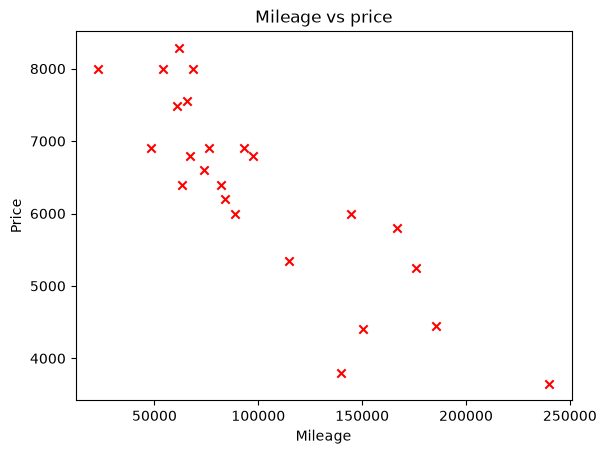

In [13]:
import matplotlib.pyplot as plt
plt.scatter(x_train, y_train, marker='x', c='r')
plt.title("Mileage vs price")
plt.ylabel('Price')
plt.xlabel('Mileage')
plt.show()

In [12]:
def compute_model(mileage, theta0, theta1):
    m = mileage.shape[0]
    f_wb = np.zeros(m)
    for i in range(m):
        f_wb[i] = theta0 + (theta1 * mileage[i])
    return f_wb

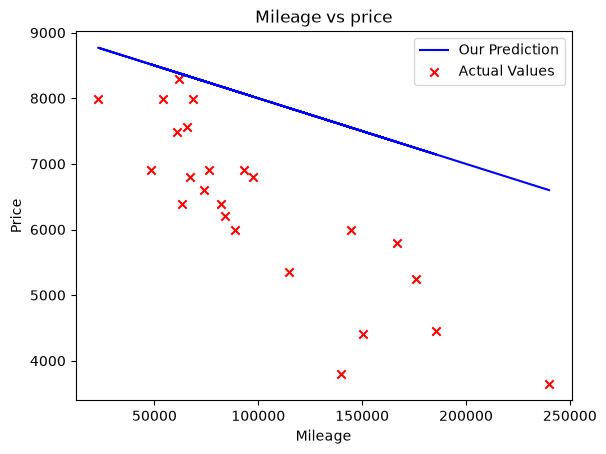

In [35]:
theta0 = 9000
theta1 = -0.01
# theta0 = 8499.599649882372
# theta1 = -0.021448963591218763
tmp_f_wb = compute_model(x_train, theta0, theta1)
plt.plot(x_train, tmp_f_wb, c = 'b', label='Our Prediction')
plt.scatter(x_train, y_train, marker='x', c='r', label='Actual Values')
plt.title("Mileage vs price")
plt.ylabel('Price')
plt.xlabel('Mileage')
plt.legend()
plt.show()

Cost function -> How well our model is predicting the target price of the house.

1. Calculate error on each predictions of the price of car. errors[i] = prediction[i] - cost[i]

In [36]:
errors = tmp_f_wb - y_train
print(errors)
square_errors = errors ** 2
print(square_errors)
sum_square_errors = square_errors.sum()
print(f"The total error sum is {sum_square_errors}")

[2950.   3802.   3095.   2694.7  1990.   2502.   1532.   2120.   1556.
 1960.   1789.71 1979.4  1660.   1225.   1530.   1339.75 1617.65 1170.
  900.51  788.26  470.    325.    781.01   92.11]
[8.70250000e+06 1.44552040e+07 9.57902500e+06 7.26140809e+06
 3.96010000e+06 6.26000400e+06 2.34702400e+06 4.49440000e+06
 2.42113600e+06 3.84160000e+06 3.20306188e+06 3.91802436e+06
 2.75560000e+06 1.50062500e+06 2.34090000e+06 1.79493006e+06
 2.61679152e+06 1.36890000e+06 8.10918260e+05 6.21353828e+05
 2.20900000e+05 1.05625000e+05 6.09976620e+05 8.48425210e+03]
The total error sum is 85198491.879


cost function = 1/2m * mean square error

In [42]:
m = len(y_train)
cost_function = (1/(2*m)) * sum_square_errors
print(cost_function)

1774968.5808124999


![Gradient](math_equation.png)

Gradient descent

The partial derivative of cost function is gradient and using gradient times learning rate which we are going to substract from our previous theta1 and theta2 repeatedly until we reach the minimum level. The gradient * learning rate = tmpθ₀ & tmpθ₁

# Partial Derivatives (and Why They Matter for Gradient Descent)

A **partial derivative** is a derivative for a function with more than one variable. It answers:

> "What happens to the function if I change only this one variable while keeping the others fixed?"

## Simple Example

Suppose:

$$f(x, y) = x^2 + 3y$$

This function has two variables, $x$ and $y$.

### Partial derivative with respect to $x$

To compute $\frac{\partial f}{\partial x}$, we pretend $y$ is a constant. The term $3y$ disappears because we're not changing $y$:

$$\boxed{\frac{\partial f}{\partial x} = 2x}$$

### Partial derivative with respect to $y$

To compute $\frac{\partial f}{\partial y}$, we keep $x$ fixed. The term $x^2$ is treated as a constant:

$$\boxed{\frac{\partial f}{\partial y} = 3}$$

## Why This Matters for Gradient Descent

The cost function has two parameters:

$$J(\theta_0, \theta_1)$$

So we need to know:

- How does the cost change if I change only $\theta_0$?

  $$\frac{\partial J}{\partial \theta_0}$$

- How does the cost change if I change only $\theta_1$?

  $$\frac{\partial J}{\partial \theta_1}$$

Those two partial derivatives together give us the **gradient**:

$$\boxed{\text{gradient} = \left[\frac{\partial J}{\partial \theta_0},\ \frac{\partial J}{\partial \theta_1}\right]}$$

## Summary

| Concept | Meaning |
|---|---|
| **Derivative** | How a function changes with one variable |
| **Partial derivative** | How a function changes with one variable while keeping the other variables fixed |
| **Gradient** | All the partial derivatives together, as a vector |
# Gradient Descent Update Formulas (Linear Regression)

## The formulas

$$tmp\theta_0 = \text{learningRate} \cdot \frac{1}{m} \sum_{i=0}^{m-1} \left( \text{estimatePrice}(\text{mileage}[i]) - \text{price}[i] \right)$$

$$tmp\theta_1 = \text{learningRate} \cdot \frac{1}{m} \sum_{i=0}^{m-1} \left( \text{estimatePrice}(\text{mileage}[i]) - \text{price}[i] \right) \cdot \text{mileage}[i]$$

## What is $m$?

$m$ is the **number of training examples** (the number of rows in your dataset, i.e. how many (mileage, price) pairs you have).

- The sum runs from $i = 0$ to $m-1$, so it visits every data point once.
- Dividing by $m$ turns the sum into an **average** error over the dataset.


/var/folders/z5/st9b9tcd74j12k31wtb87y6c0000gn/T/ipykernel_26172/538072622.py:10: RuntimeWarning: overflow encountered in scalar multiply
  tmp1 = LEARNING_RATE * sum(errors[i] * km[i] for i in range(m)) / m
/var/folders/z5/st9b9tcd74j12k31wtb87y6c0000gn/T/ipykernel_26172/538072622.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  theta1 -= tmp1


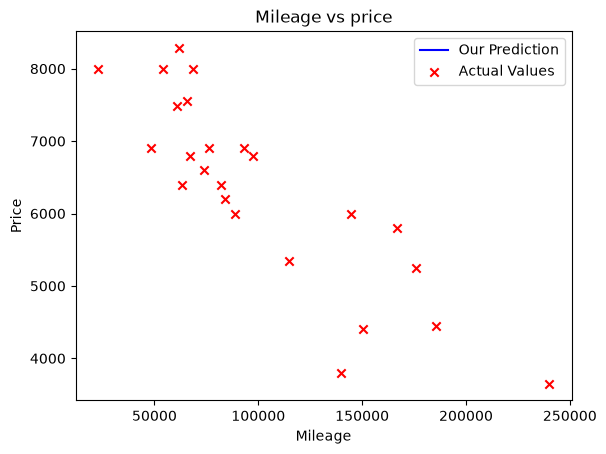

In [54]:
LEARNING_RATE = 0.1
ITERATIONS = 5000

def train(km, price):
    m = len(km)
    theta0, theta1 = 0.0, 0.0
    for _ in range(ITERATIONS):
        errors = [(theta0 + theta1 * km[i]) - price[i] for i in range(m)]
        tmp0 = LEARNING_RATE * sum(errors) / m
        tmp1 = LEARNING_RATE * sum(errors[i] * km[i] for i in range(m)) / m
        theta0 -= tmp0
        theta1 -= tmp1
    return theta0, theta1

theta0, theta1 = train(x_train, y_train)

tmp_f_wb = compute_model(x_train, theta0, theta1)
plt.plot(x_train, tmp_f_wb, c = 'b', label='Our Prediction')
plt.scatter(x_train, y_train, marker='x', c='r', label='Actual Values')
plt.title("Mileage vs price")
plt.ylabel('Price')
plt.xlabel('Mileage')
plt.legend()
plt.show()

Normalization help solve the overflow problem

In [51]:
x_min = x_train.min()
x_max = x_train.max()

x = (x_train - x_min) / (x_max - x_min)
print(x)

[1.         0.53846366 0.58774948 0.74910295 0.70520633 0.42330989
 0.66282974 0.30447119 0.56011257 0.28144044 0.27236171 0.18498763
 0.23537893 0.34362347 0.20313587 0.24470638 0.11670144 0.3228958
 0.17526405 0.19702811 0.1432559  0.21004509 0.         0.17913321]


The training model with normalization looks below

8494.699919906481 -0.021437587588093176


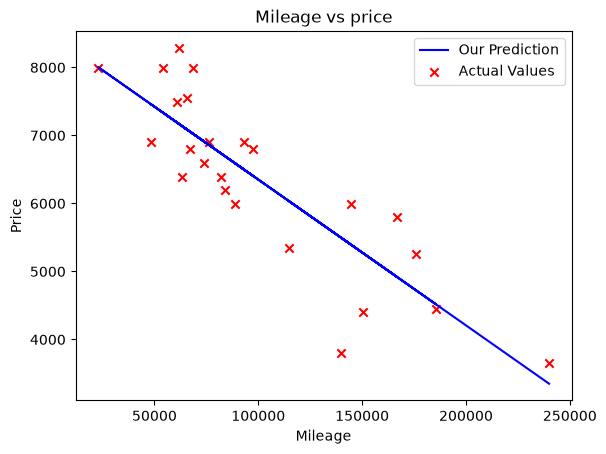

In [ ]:
def train(km: list[float], price: list[float]) -> tuple[float, float]:
    """Train the data using gradient descent."""
    m = len(km)
    # Normalize mileage to [0, 1] so gradient descent converges
    # with a reasonalbe learning curve
    km_min, km_max = min(km), max(km)
    scale = km_max - km_min
    x = [(k - km_min) / scale for k in km]
    theta0, theta1 = 0.0, 0.0
    for _ in range(ITERATIONS):
        errors = [(theta0 + theta1 * x[i]) - price[i] for i in range(m)]
        tmp0 = LEARNING_RATE * sum(errors) / m
        tmp1 = LEARNING_RATE * sum(errors[i] * x[i] for i in range(m)) / m
        theta0 -= tmp0
        theta1 -= tmp1
    real_theta1 = theta1 / scale
    real_theta0 = theta0 - real_theta1 * km_min
    return real_theta0, real_theta1
theta0, theta1 = train(x_train, y_train)
print(theta0, theta1)
tmp_f_wb = compute_model(x_train, theta0, theta1)
plt.plot(x_train, tmp_f_wb, c = 'b', label='Our Prediction')
plt.scatter(x_train, y_train, marker='x', c='r', label='Actual Values')
plt.title("Mileage vs price")
plt.ylabel('Price')
plt.xlabel('Mileage')
plt.legend()
plt.show()